# Semi Supervised Learning: Label Propagation on Mushrooms

Labeling data is expensive, so we destroy 70 percent of the training labels in each class and let LabelSpreading infer them back from the geometry of the data. An SVC trained on the inferred labels is then scored on untouched test data.

The mushroom features are categorical, so similarity is measured with the Gower distance.

In [1]:
import matplotlib
matplotlib.use("Agg")  # headless backend so figures render without a screen
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

class Image:
    """Minimal stand in for IPython display Image: embeds a PNG file."""
    def __init__(self, path):
        self.path = path
    def _repr_png_(self):
        with open(self.path, "rb") as f:
            return f.read()
    def __repr__(self):
        return f"<chart PNG: {self.path}>"

## Load the mushroom data

In [2]:
mush = pd.read_csv("../data/mushrooms.csv").head(100)
print("rows:", len(mush), "| features:", mush.shape[1] - 1)
print("classes:", mush["class"].value_counts().to_dict())
mush.head(3)

rows: 100 | features: 22
classes: {'e': 84, 'p': 16}


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m


## Encode labels as integers

In [3]:
# pandas 3 leaves object dtype after replace, so cast to int for sklearn
y = mush["class"].replace({"e": 0, "p": 1}).astype(int).values
X = mush.drop(columns=["class"]).values
print("encoded:", dict(zip(*np.unique(y, return_counts=True))), "(0 is edible, 1 is poisonous)")

encoded: {np.int64(0): np.int64(84), np.int64(1): np.int64(16)} (0 is edible, 1 is poisonous)


## Helpers: Gower distance plus label destruction

In [4]:

from scipy.spatial import distance
from sklearn.utils import validation
from sklearn.metrics import pairwise
from scipy.sparse import issparse

# Gower distance implementation shared by Marcelo Beckmann for the scikit learn project.
# Kept here so the notebook runs on its own.


# This is a utility function used by gower_distances below.
def check_pairwise_arrays(X, Y, precomputed=False, dtype=None):
    X, Y, dtype_float = pairwise._return_float_dtype(X, Y)

    warn_on_dtype = dtype is not None
    estimator = "check_pairwise_arrays"
    if dtype is None:
        dtype = dtype_float

    if Y is X or Y is None:
        X = Y = validation.check_array(
            X, accept_sparse="csr", dtype=dtype, estimator=estimator
        )
    else:
        X = validation.check_array(
            X, accept_sparse="csr", dtype=dtype, estimator=estimator
        )
        Y = validation.check_array(
            Y, accept_sparse="csr", dtype=dtype, estimator=estimator
        )

    if precomputed:
        if X.shape[1] != Y.shape[0]:
            raise ValueError(
                "Precomputed metric requires shape "
                "(n_queries, n_indexed). Got (%d, %d) "
                "for %d indexed." % (X.shape[0], X.shape[1], Y.shape[0])
            )
    elif X.shape[1] != Y.shape[1]:
        raise ValueError(
            "Incompatible dimension for X and Y matrices: "
            "X.shape[1] == %d while Y.shape[1] == %d" % (X.shape[1], Y.shape[1])
        )

    return X, Y


# gower_distances: see header below for details.
#
# For purposes of this assignment you can simply call it like this on a dataset X (n instances):
# D = gower_distances(X)
#
# which results an n x n distance matrix.
#


def gower_distances(X, Y=None, feature_weight=None, categorical_features=None):
    """Gower distance between rows of X and rows of Y.

    Works on mixed categorical and numeric data. Call as D = gower_distances(X)
    to get an n by n distance matrix.
    """

    if issparse(X) or issparse(Y):
        raise TypeError("Sparse matrices are not supported for gower distance")

    y_none = Y is None

    # It is necessary to convert to ndarray in advance to define the dtype
    if not isinstance(X, np.ndarray):
        X = np.asarray(X)

    # this is necessary as strangelly the validator is rejecting
    #  numeric arrays with NaN
    # array_type = np.object

    # array_type = object replaces above due to deprecation of
    # np.object.
    array_type = object

    if np.issubdtype(X.dtype, np.number) and (
        np.isfinite(X.sum()) or np.isfinite(X).all()
    ):
        array_type = type(np.zeros(1, X.dtype).flat[0])

    X, Y = check_pairwise_arrays(X, Y, precomputed=False, dtype=array_type)

    n_rows, n_cols = X.shape

    if categorical_features is None:
        categorical_features = np.zeros(n_cols, dtype=bool)
        for col in range(n_cols):
            # In numerical columns, None is converted to NaN,
            # and the type of NaN is recognized as a number subtype
            if not np.issubdtype(type(X[0, col]), np.number):
                categorical_features[col] = True
    else:
        categorical_features = np.array(categorical_features)

    # if categorical_features.dtype == np.int32:
    # np.int deprecated
    # if np.issubdtype(categorical_features.dtype, np.int):

    if np.issubdtype(categorical_features.dtype, np.int64):
        new_categorical_features = np.zeros(n_cols, dtype=bool)
        new_categorical_features[categorical_features] = True
        categorical_features = new_categorical_features

    # print(categorical_features)

    # Categorical columns
    X_cat = X[:, categorical_features]

    # Numerical columns
    X_num = X[:, np.logical_not(categorical_features)]
    ranges_of_numeric = None
    max_of_numeric = None

    # Calculates the normalized ranges and max values of numeric values
    _, num_cols = X_num.shape
    ranges_of_numeric = np.zeros(num_cols)
    max_of_numeric = np.zeros(num_cols)
    for col in range(num_cols):
        col_array = X_num[:, col].astype(np.float32)
        max = np.nanmax(col_array)
        min = np.nanmin(col_array)

        if np.isnan(max):
            max = 0.0
        if np.isnan(min):
            min = 0.0
        max_of_numeric[col] = max
        ranges_of_numeric[col] = (1 - min / max) if (max != 0) else 0.0

    # This is to normalize the numeric values between 0 and 1.
    X_num = np.divide(
        X_num, max_of_numeric, out=np.zeros_like(X_num), where=max_of_numeric != 0
    )

    if feature_weight is None:
        feature_weight = np.ones(n_cols)

    feature_weight_cat = feature_weight[categorical_features]
    feature_weight_num = feature_weight[np.logical_not(categorical_features)]

    y_n_rows, _ = Y.shape

    dm = np.zeros((n_rows, y_n_rows), dtype=np.float32)

    feature_weight_sum = feature_weight.sum()

    Y_cat = None
    Y_num = None

    if not y_none:
        Y_cat = Y[:, categorical_features]
        Y_num = Y[:, np.logical_not(categorical_features)]
        # This is to normalize the numeric values between 0 and 1.
        Y_num = np.divide(
            Y_num, max_of_numeric, out=np.zeros_like(Y_num), where=max_of_numeric != 0
        )
    else:
        Y_cat = X_cat
        Y_num = X_num

    for i in range(n_rows):
        j_start = i

        # for non square results
        if n_rows != y_n_rows:
            j_start = 0

        Y_cat[j_start:n_rows, :]
        Y_num[j_start:n_rows, :]
        result = _gower_distance_row(
            X_cat[i, :],
            X_num[i, :],
            Y_cat[j_start:n_rows, :],
            Y_num[j_start:n_rows, :],
            feature_weight_cat,
            feature_weight_num,
            feature_weight_sum,
            categorical_features,
            ranges_of_numeric,
            max_of_numeric,
        )
        dm[i, j_start:] = result
        dm[i:, j_start] = result

    return dm


def _gower_distance_row(
    xi_cat,
    xi_num,
    xj_cat,
    xj_num,
    feature_weight_cat,
    feature_weight_num,
    feature_weight_sum,
    categorical_features,
    ranges_of_numeric,
    max_of_numeric,
):
    # categorical columns
    sij_cat = np.where(xi_cat == xj_cat, np.zeros_like(xi_cat), np.ones_like(xi_cat))
    sum_cat = np.multiply(feature_weight_cat, sij_cat).sum(axis=1)

    # numerical columns
    abs_delta = np.absolute(xi_num - xj_num)
    sij_num = np.divide(
        abs_delta,
        ranges_of_numeric,
        out=np.zeros_like(abs_delta),
        where=ranges_of_numeric != 0,
    )

    sum_num = np.multiply(feature_weight_num, sij_num).sum(axis=1)
    sums = np.add(sum_cat, sum_num)
    sum_sij = np.divide(sums, feature_weight_sum)
    return sum_sij


from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


def get_mangled_label_dataset(X_train, y_train, frac_0, frac_1):
    """Destroy a fraction of the training labels.

    frac_0 and frac_1 are the probability of destroying a class 0 label
    and a class 1 label. Destroyed labels are marked with minus one.
    Returns the labeled subset plus the complete training set with
    destroyed labels.
    """

    rng = np.random.RandomState(0)

    X_train_0 = X_train[y_train == 0]
    y_train_0 = y_train[y_train == 0]

    X_train_1 = X_train[y_train == 1]
    y_train_1 = y_train[y_train == 1]

    X_train_complete = np.vstack((X_train_0, X_train_1))
    y_train_complete = np.concatenate((y_train_0, y_train_1))

    random_unlabeled_points_0 = rng.rand(len(y_train_0)) < frac_0
    random_unlabeled_points_1 = rng.rand(len(y_train_1)) < frac_1
    random_unlabeled_points = np.concatenate(
        (random_unlabeled_points_0, random_unlabeled_points_1)
    )

    random_labeled_points_0 = np.logical_not(random_unlabeled_points_0)
    random_labeled_points_1 = np.logical_not(random_unlabeled_points_1)

    labeled_subset_X_train_0 = X_train_0[random_labeled_points_0]
    labeled_subset_X_train_1 = X_train_1[random_labeled_points_1]
    labeled_subset_y_train_0 = y_train_0[random_labeled_points_0]
    labeled_subset_y_train_1 = y_train_1[random_labeled_points_1]

    labeled_subset_X_train = np.vstack(
        (labeled_subset_X_train_0, labeled_subset_X_train_1)
    )
    labeled_subset_y_train = np.concatenate(
        (labeled_subset_y_train_0, labeled_subset_y_train_1)
    )

    labels_train_with_destroyed = np.copy(y_train_complete)
    labels_train_with_destroyed[random_unlabeled_points] = -1

    return (
        labeled_subset_X_train,
        labeled_subset_y_train,
        X_train_complete,
        labels_train_with_destroyed,
    )


## Measure similarity with the Gower distance matrix

In [5]:
D = gower_distances(X)
print("Gower distance matrix:", D.shape)

Gower distance matrix: (100, 100)


## Split into train and test, scale each part on its own

In [6]:
X_train, X_test, y_train, y_test = train_test_split(D, y, random_state=0)
X_train = StandardScaler().fit(X_train).transform(X_train)
X_test = StandardScaler().fit(X_test).transform(X_test)
print("train:", X_train.shape, "| test:", X_test.shape)
print("train classes:", dict(zip(*np.unique(y_train, return_counts=True))))

train: (75, 100) | test: (25, 100)
train classes: {np.int64(0): np.int64(66), np.int64(1): np.int64(9)}


## Destroy 70 percent of the training labels in each class

In [7]:
_, _, X_complete, y_destroyed = get_mangled_label_dataset(X_train, y_train, 0.7, 0.7)
kept = int((y_destroyed != -1).sum())
print(f"labels kept: {kept} of {len(y_destroyed)}")

labels kept: 20 of 75


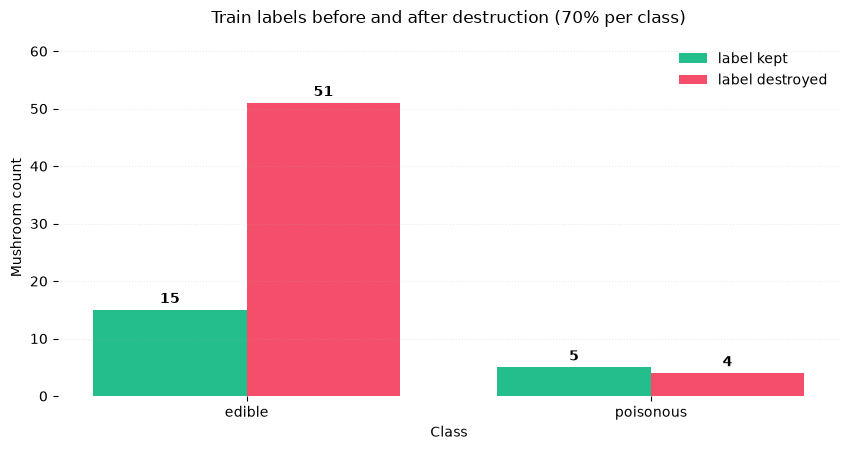

In [8]:
n0 = int((y_train == 0).sum())
kept0 = int((y_destroyed[:n0] != -1).sum())
kept1 = int((y_destroyed[n0:] != -1).sum())
kept_counts = np.array([kept0, kept1])
destroyed_counts = np.array([n0 - kept0, (len(y_train) - n0) - kept1])

fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(2)
w = 0.38
ax.bar(x - w / 2, kept_counts, w, label="label kept", color="#10B981", alpha=0.92)
ax.bar(x + w / 2, destroyed_counts, w, label="label destroyed", color="#F43F5E", alpha=0.92)
for i in range(2):
    ax.text(i - w / 2, kept_counts[i] + 1.2, str(kept_counts[i]), ha="center", fontweight="bold")
    ax.text(i + w / 2, destroyed_counts[i] + 1.2, str(destroyed_counts[i]), ha="center", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(["edible", "poisonous"])
ax.set_xlabel("Class")
ax.set_ylabel("Mushroom count")
ax.set_title("Train labels before and after destruction (70% per class)", pad=12)
ax.set_ylim(0, 62)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.25, linestyle=":")
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig("../charts/chart_label_destruction.png", bbox_inches="tight")
plt.close(fig)
Image("../charts/chart_label_destruction.png")

## LabelSpreading infers the missing labels from the graph

In [9]:
lp = LabelSpreading(kernel="knn", n_neighbors=9, max_iter=30, tol=0.001)
lp.fit(X_complete, y_destroyed)
inferred = lp.transduction_
print("inferred labels:", dict(zip(*np.unique(inferred, return_counts=True))))

inferred labels: {np.int64(0): np.int64(66), np.int64(1): np.int64(9)}


## Train an SVC on the inferred labels, score on the real test labels

In [10]:
clf = SVC().fit(X_complete, inferred)
acc = accuracy_score(y_test, clf.predict(X_test))
print(f"SVC test accuracy: {acc:.2f}")

SVC test accuracy: 0.92


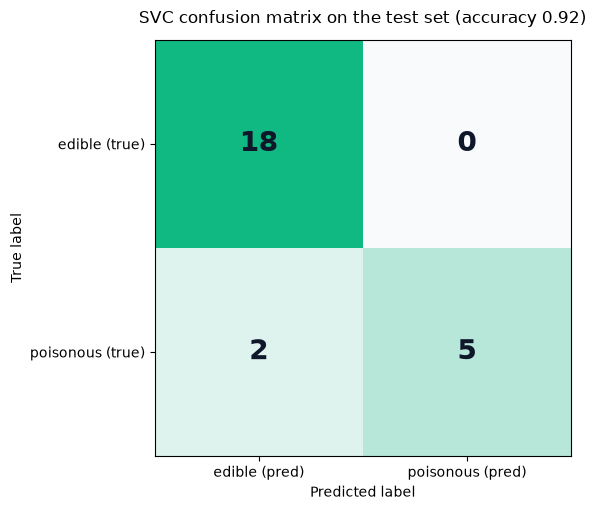

In [11]:
cm = confusion_matrix(y_test, clf.predict(X_test))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("em", ["#F8FAFC", "#10B981"], N=256)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.imshow(cm, cmap=cmap, vmin=0, vmax=18)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["edible (pred)", "poisonous (pred)"])
ax.set_yticklabels(["edible (true)", "poisonous (true)"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=20, fontweight="bold", color="#0F172A")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("SVC confusion matrix on the test set (accuracy 0.92)", pad=12)
fig.tight_layout()
fig.savefig("../charts/chart_confusion_matrix.png", bbox_inches="tight")
plt.close(fig)
Image("../charts/chart_confusion_matrix.png")

## Takeaway

From only 20 surviving labels out of 75, label propagation plus an SVC reaches 0.92 accuracy on the test set. The confusion matrix tells the honest story: all 18 edible mushrooms are caught correctly, while 2 of the 7 poisonous ones slip through as edible. That is the caveat of this demo. An accuracy of 0.92 looks great until you remember the cost of one wrong bite.